# Case 3 – Nuclear + Data Center + Bidirectional Grid




In [14]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')

import os
from h2integrate import EXAMPLE_DIR
os.chdir(EXAMPLE_DIR / '32_nuclear_DC_case_3')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from h2integrate.core.h2integrate_model import H2IntegrateModel

warnings.filterwarnings('ignore')  # suppress OpenMDAO recording warnings

DC_DEMAND_MW = 2000  # fixed data-center demand [MW]

## 2. Load & inspect base model

In [15]:
h2i = H2IntegrateModel('nuclear_datacenter_config_case_3.yaml')
h2i.setup()

cap_kw = h2i.prob.get_val('plant.nuclear.QuinnNuclearPerformanceModel.system_capacity', units='kW')
icx_kw = h2i.prob.get_val('plant.grid.GridPerformanceModel.interconnection_size', units='kW')

print(f"Default nuclear capacity : {cap_kw[0]/1e3:.0f} MW")
print(f"Grid interconnection size: {icx_kw[0]/1e3:.0f} MW")
print(f"DC demand (fixed)        : {DC_DEMAND_MW} MW")

Default nuclear capacity : 1000 MW
Grid interconnection size: 3000 MW
DC demand (fixed)        : 2000 MW


## 3. 1-D Nuclear Size Sweep

DC demand is fixed at 2000 MW.  
The grid interconnection size is set to `max(nuclear_mw, DC_DEMAND_MW)` so it never clips either buying or selling flows.

In [16]:
NUCLEAR_SIZES_MW = [500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]

results = []
ts_data = {}   # hourly time-series keyed by nuclear_mw

for nuclear_mw in NUCLEAR_SIZES_MW:
    nuclear_kw = nuclear_mw * 1e3
    # Size grid interconnection to handle largest possible flow
    icx_kw_val = max(nuclear_kw, DC_DEMAND_MW * 1e3)

    h2i.prob.set_val('nuclear.system_capacity',   nuclear_kw,  units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', nuclear_kw, units='kW')  # nuclear runs at full capacity
    h2i.prob.set_val('grid.interconnection_size',  icx_kw_val, units='kW')

    h2i.run()

    # ---- Scalar outputs ----
    lcoe      = h2i.prob.get_val('finance_subgroup_nuclear.LCOE', units='USD/(kW*h)')[0]
    nuc_capex = h2i.prob.get_val('nuclear.CapEx',   units='USD')[0] / 1e9
    grd_capex = h2i.prob.get_val('grid.CapEx',      units='USD')[0] / 1e6
    nuc_opex  = h2i.prob.get_val('nuclear.OpEx',    units='USD/year')[0] / 1e6
    nuc_varop = h2i.prob.get_val('nuclear.VarOpEx', units='USD/year')[0] / 1e6
    grd_opex  = h2i.prob.get_val('grid.OpEx',       units='USD/year')[0] / 1e6
    grd_varop = h2i.prob.get_val('grid.VarOpEx',    units='USD/year')[0] / 1e6  # negative = net revenue

    # ---- Time-averaged flows (kW -> MW mean) ----
    surplus_mean_mw  = h2i.prob.get_val('electrical_load_demand.electricity_unused_commodity', units='kW').mean() / 1e3
    shortfall_mean_mw = h2i.prob.get_val('electrical_load_demand.electricity_unmet_demand',   units='kW').mean() / 1e3
    sold_mean_mw     = h2i.prob.get_val('grid.electricity_sold',  units='kW').mean() / 1e3
    bought_mean_mw   = h2i.prob.get_val('grid.electricity_out',   units='kW').mean() / 1e3

    # ---- Annual energy (MWh) ----
    sold_gwh   = h2i.prob.get_val('grid.electricity_sold', units='kW').sum() * 1e-6   # kW*h -> GWh
    bought_gwh = h2i.prob.get_val('grid.electricity_out',  units='kW').sum() * 1e-6

    results.append({
        'nuclear_mw':          nuclear_mw,
        'lcoe_per_mwh':        lcoe * 1000,          # USD/MWh
        'capacity_factor':     h2i.prob.get_val('nuclear.capacity_factor')[0],
        # Flows
        'surplus_mean_mw':     surplus_mean_mw,
        'shortfall_mean_mw':   shortfall_mean_mw,
        'sold_to_grid_mw':     sold_mean_mw,
        'bought_from_grid_mw': bought_mean_mw,
        'sold_gwh':            sold_gwh,
        'bought_gwh':          bought_gwh,
        # Costs ($B / $M)
        'nuclear_capex_B$':    nuc_capex,
        'grid_capex_M$':       grd_capex,
        'nuclear_opex_M$':     nuc_opex,
        'nuclear_varopex_M$':  nuc_varop,
        'grid_opex_M$':        grd_opex,
        'grid_varopex_M$':     grd_varop,   # negative = net revenue earned
        'net_grid_revenue_M$': -grd_varop,  # positive = revenue (buy_cost - sell_revenue sign flipped)
    })

    ts_data[nuclear_mw] = {
        'nuclear_out_mw':    h2i.prob.get_val('nuclear.electricity_out',                           units='kW') / 1e3,
        'surplus_mw':        h2i.prob.get_val('electrical_load_demand.electricity_unused_commodity', units='kW') / 1e3,
        'shortfall_mw':      h2i.prob.get_val('electrical_load_demand.electricity_unmet_demand',   units='kW') / 1e3,
        'sold_to_grid_mw':   h2i.prob.get_val('grid.electricity_sold',                            units='kW') / 1e3,
        'bought_from_grid_mw': h2i.prob.get_val('grid.electricity_out',                           units='kW') / 1e3,
    }

df = pd.DataFrame(results)
df

,nuclear_mw,lcoe_per_mwh,capacity_factor,surplus_mean_mw,shortfall_mean_mw,sold_to_grid_mw,bought_from_grid_mw,sold_gwh,bought_gwh,nuclear_capex_B$,grid_capex_M$,nuclear_opex_M$,nuclear_varopex_M$,grid_opex_M$,grid_varopex_M$,net_grid_revenue_M$
0,500,352.178694,1.0,0.0,1500.0,0.0,1500.0,0.0,13140.0,3.606101,200.0,75.0,65.70,10.00,1051.2,-1051.2
1,750,242.722722,1.0,0.0,1250.0,0.0,1250.0,0.0,10950.0,5.089972,200.0,112.5,98.55,10.00,876.0,-876.0
2,1000,187.127990,1.0,0.0,1000.0,0.0,1000.0,0.0,8760.0,6.500000,200.0,150.0,131.40,10.00,700.8,-700.8
3,1250,153.278338,1.0,0.0,750.0,0.0,750.0,0.0,6570.0,7.857545,200.0,187.5,164.25,10.00,525.6,-525.6
4,1500,130.395698,1.0,0.0,500.0,0.0,500.0,0.0,4380.0,9.174680,200.0,225.0,197.10,10.00,350.4,-350.4
5,1750,113.831753,1.0,0.0,250.0,0.0,250.0,0.0,2190.0,10.459133,200.0,262.5,229.95,10.00,175.2,-175.2
6,2000,101.248398,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11.716256,200.0,300.0,262.80,10.00,0.0,-0.0
7,2250,94.756398,1.0,250.0,0.0,250.0,0.0,2190.0,0.0,12.949962,225.0,337.5,295.65,11.25,-109.5,109.5
8,2500,89.466849,1.0,500.0,0.0,500.0,0.0,4380.0,0.0,14.163232,250.0,375.0,328.50,12.50,-219.0,219.0
9,2750,85.061802,1.0,750.0,0.0,750.0,0.0,6570.0,0.0,15.358406,275.0,412.5,361.35,13.75,-328.5,328.5


## 4. 1-D Sweep – Visualizations

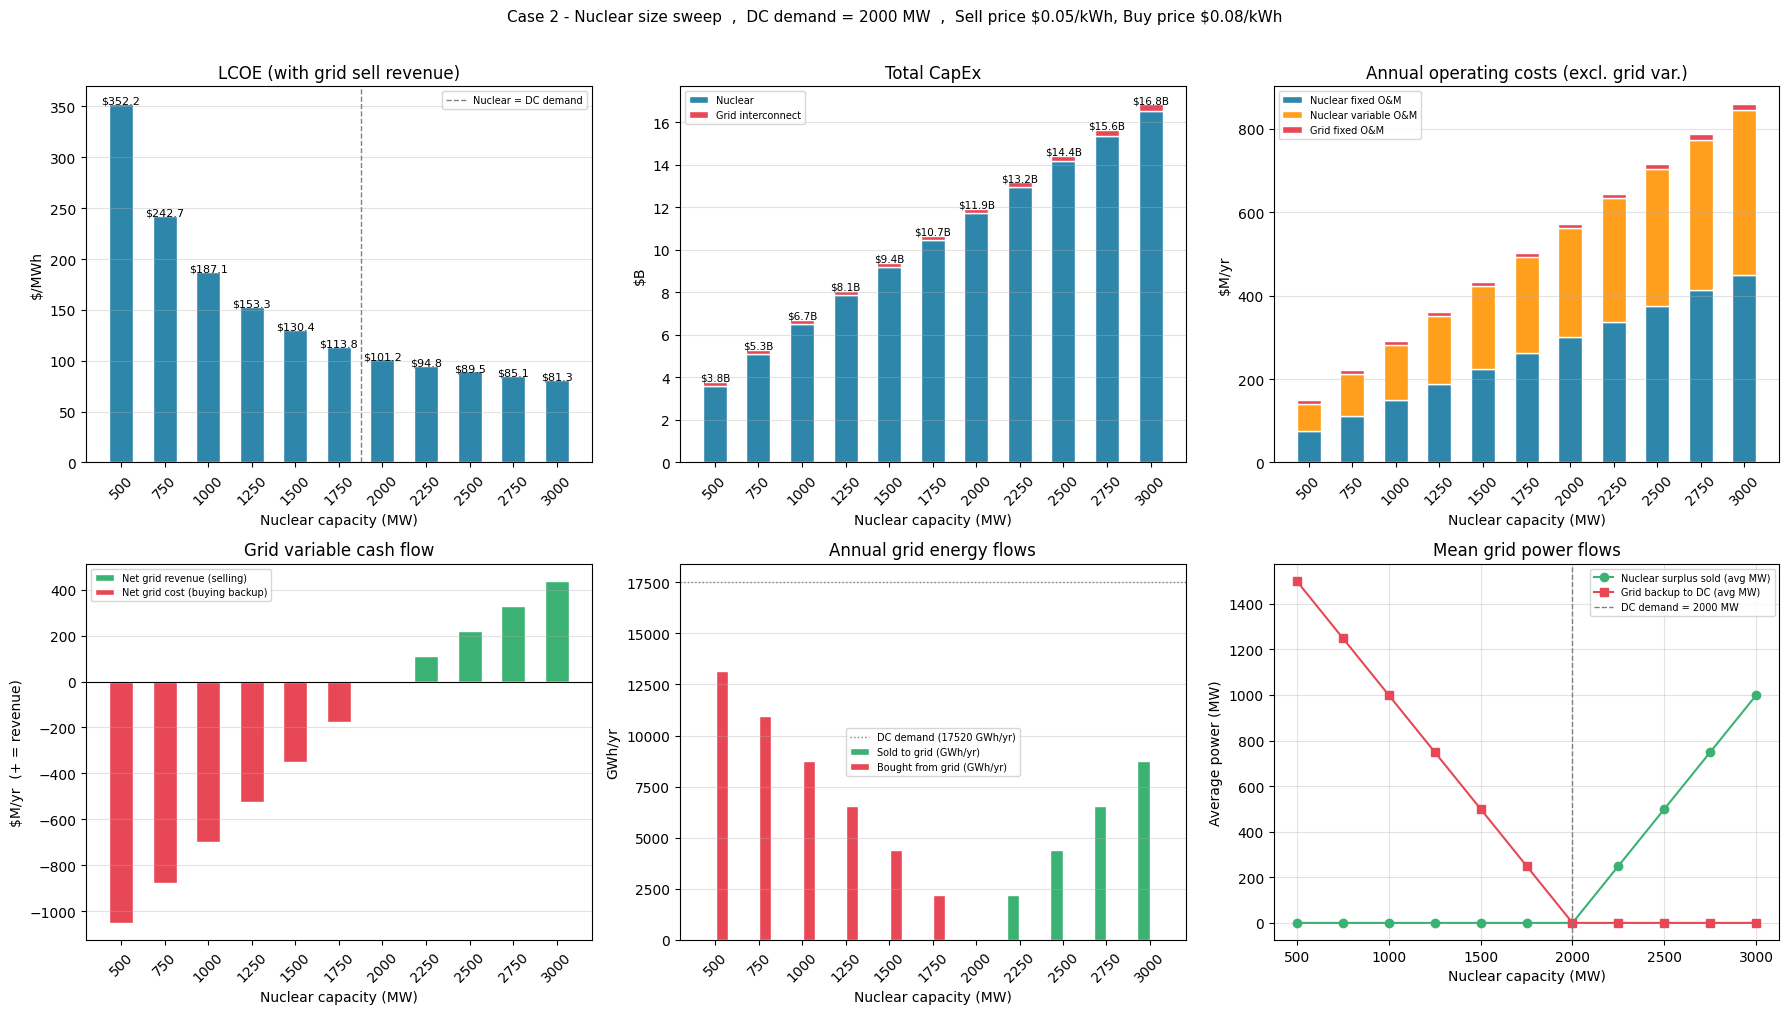

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.45, wspace=0.38)

sizes = df['nuclear_mw'].values.astype(float)
x     = np.arange(len(sizes))
labels = [str(int(s)) for s in sizes]
W = 0.55

# Color palette
C_NUC  = '#2e86ab'
C_GRD  = '#e84855'
C_REV  = '#3bb273'
C_COST = '#ff9f1c'

# ── 1. LCOE ──────────────────────────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, df['lcoe_per_mwh'], W, color=C_NUC, edgecolor='white')
for xi, v in zip(x, df['lcoe_per_mwh']):
    ax.text(xi, v + 0.3, f'${v:.1f}', ha='center', fontsize=8)
ax.axvline(x=NUCLEAR_SIZES_MW.index(DC_DEMAND_MW) - 0.5, color='gray',
           linestyle='--', lw=1, label='Nuclear = DC demand')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$/MWh')
ax.set_title('LCOE (with grid sell revenue)')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 2. CapEx breakdown ────────────────────────────────────────────────────────
ax = axes[0, 1]
nuc_cx  = df['nuclear_capex_B$'].values
grd_cx  = df['grid_capex_M$'].values / 1e3
ax.bar(x, nuc_cx, W, color=C_NUC, label='Nuclear',          edgecolor='white')
ax.bar(x, grd_cx, W, bottom=nuc_cx, color=C_GRD, label='Grid interconnect', edgecolor='white')
for xi, n, g in zip(x, nuc_cx, grd_cx):
    ax.text(xi, (n + g) + 0.05, f'${n+g:.1f}B', ha='center', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$B')
ax.set_title('Total CapEx')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 3. Annual OpEx breakdown ──────────────────────────────────────────────────
ax = axes[0, 2]
op  = df['nuclear_opex_M$'].values
vop = df['nuclear_varopex_M$'].values
gop = df['grid_opex_M$'].values
ax.bar(x, op,      W, color=C_NUC,  label='Nuclear fixed O&M',    edgecolor='white')
ax.bar(x, vop,     W, bottom=op,           color=C_COST, label='Nuclear variable O&M', edgecolor='white')
ax.bar(x, gop,     W, bottom=op+vop,       color=C_GRD,  label='Grid fixed O&M',       edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$M/yr')
ax.set_title('Annual operating costs (excl. grid var.)')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 4. Grid variable revenue / cost ──────────────────────────────────────────
ax = axes[1, 0]
grd_rev  = np.clip(-df['grid_varopex_M$'].values, 0, None)   # positive = net revenue (sell > buy)
grd_cost = np.clip( df['grid_varopex_M$'].values, 0, None)   # positive = net cost (buy > sell)
ax.bar(x, grd_rev,  W, color=C_REV,  label='Net grid revenue (selling)',  edgecolor='white')
ax.bar(x, -grd_cost, W, color=C_GRD, label='Net grid cost (buying backup)', edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('$M/yr  (+ = revenue)')
ax.set_title('Grid variable cash flow')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 5. Energy flows (annual GWh) ─────────────────────────────────────────────
ax = axes[1, 1]
sold   = df['sold_gwh'].values
bought = df['bought_gwh'].values
ax.bar(x - 0.15, sold,   0.28, color=C_REV,  label='Sold to grid (GWh/yr)',  edgecolor='white')
ax.bar(x + 0.15, bought, 0.28, color=C_GRD,  label='Bought from grid (GWh/yr)', edgecolor='white')
dc_gwh = DC_DEMAND_MW * 8760 / 1e3   # GWh/yr
ax.axhline(dc_gwh, color='gray', linestyle=':', lw=1, label=f'DC demand ({dc_gwh:.0f} GWh/yr)')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('GWh/yr')
ax.set_title('Annual grid energy flows')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.35)

# ── 6. Mean power flows (MW) ──────────────────────────────────────────────────
ax = axes[1, 2]
ax.plot(sizes, df['sold_to_grid_mw'],     'o-', color=C_REV,  label='Nuclear surplus sold (avg MW)')
ax.plot(sizes, df['bought_from_grid_mw'], 's-', color=C_GRD,  label='Grid backup to DC (avg MW)')
ax.axvline(DC_DEMAND_MW, color='gray', linestyle='--', lw=1, label=f'DC demand = {DC_DEMAND_MW} MW')
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('Average power (MW)')
ax.set_title('Mean grid power flows')
ax.legend(fontsize=7); ax.grid(alpha=0.35)

plt.suptitle(
    f'Case 2 - Nuclear size sweep  ,  DC demand = {DC_DEMAND_MW} MW  ,  '
    f'Sell price \$0.05/kWh, Buy price \$0.08/kWh',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('case3_1d_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
8760*2000

17520000

## 6. 2-D Sweep – Nuclear Size × Grid Sell Price

Fixed buy price (`$0.08/kWh`). Vary nuclear size (500–3000 MW) and sell price (\$0.03–\$0.10/kWh).

This shows how the market price for exported electricity shifts the cost-optimal nuclear size.

In [20]:
SWEEP2_NUC_MW    = [500, 1000, 1500, 2000, 2500, 3000]
SWEEP2_SELL_PRICE = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10]  # $/kWh

# Result matrix: rows = nuclear_mw, cols = sell_price
lcoe_matrix   = np.zeros((len(SWEEP2_NUC_MW), len(SWEEP2_SELL_PRICE)))
varop_matrix  = np.zeros_like(lcoe_matrix)

for i, nuclear_mw in enumerate(SWEEP2_NUC_MW):
    nuclear_kw = nuclear_mw * 1e3
    icx_kw_val = max(nuclear_kw, DC_DEMAND_MW * 1e3)

    h2i.prob.set_val('nuclear.system_capacity',    nuclear_kw,  units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', nuclear_kw,  units='kW')
    h2i.prob.set_val('grid.interconnection_size',  icx_kw_val,  units='kW')

    for j, sell_p in enumerate(SWEEP2_SELL_PRICE):
        h2i.prob.set_val('grid.electricity_sell_price', sell_p, units='USD/(kW*h)')

        h2i.run()

        lcoe_matrix[i, j]  = h2i.prob.get_val(
            'finance_subgroup_nuclear.LCOE', units='USD/(kW*h)')[0] * 1000  # $/MWh
        varop_matrix[i, j] = h2i.prob.get_val(
            'grid.VarOpEx', units='USD/year')[0] / 1e6  # $M/yr

    print(f'  Nuclear {nuclear_mw} MW done')

# Reset sell price to default
h2i.prob.set_val('grid.electricity_sell_price', 0.05, units='USD/(kW*h)')
print('2-D sweep complete.')

  Nuclear 500 MW done
  Nuclear 1000 MW done
  Nuclear 1500 MW done
  Nuclear 2000 MW done
  Nuclear 2500 MW done
  Nuclear 3000 MW done
2-D sweep complete.


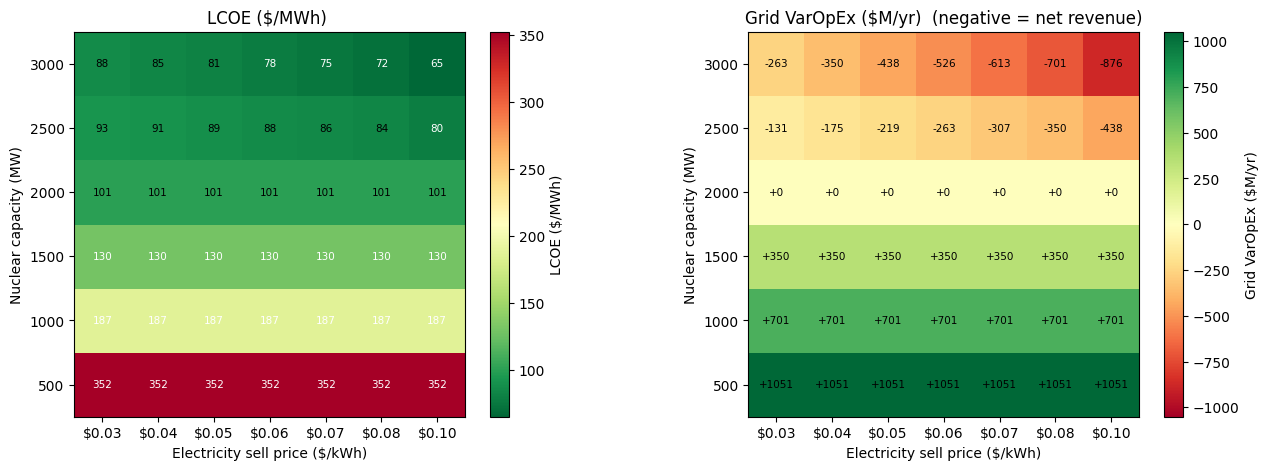

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plt.subplots_adjust(wspace=0.38)

sell_labels = [f'${p:.2f}' for p in SWEEP2_SELL_PRICE]
nuc_labels  = [str(mw) for mw in SWEEP2_NUC_MW]

# ── LCOE heatmap ─────────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(lcoe_matrix, aspect='auto', cmap='RdYlGn_r', origin='lower')
ax.set_xticks(range(len(SWEEP2_SELL_PRICE))); ax.set_xticklabels(sell_labels)
ax.set_yticks(range(len(SWEEP2_NUC_MW)));     ax.set_yticklabels(nuc_labels)
ax.set_xlabel('Electricity sell price ($/kWh)')
ax.set_ylabel('Nuclear capacity (MW)')
ax.set_title('LCOE ($/MWh) ')
plt.colorbar(im, ax=ax, label='LCOE ($/MWh)')
for (i, j), val in np.ndenumerate(lcoe_matrix):
    ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7.5,
            color='black' if 80 < val < 130 else 'white')

# ── Grid VarOpEx heatmap ──────────────────────────────────────────────────────
ax = axes[1]
vmax = np.abs(varop_matrix).max()
im2 = ax.imshow(varop_matrix, aspect='auto', cmap='RdYlGn', origin='lower',
                vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(SWEEP2_SELL_PRICE))); ax.set_xticklabels(sell_labels)
ax.set_yticks(range(len(SWEEP2_NUC_MW)));     ax.set_yticklabels(nuc_labels)
ax.set_xlabel('Electricity sell price ($/kWh)')
ax.set_ylabel('Nuclear capacity (MW)')
ax.set_title('Grid VarOpEx ($M/yr)  (negative = net revenue)')
plt.colorbar(im2, ax=ax, label='Grid VarOpEx ($M/yr)')
for (i, j), val in np.ndenumerate(varop_matrix):
    ax.text(j, i, f'{val:+.0f}', ha='center', va='center', fontsize=7.5)


plt.savefig('case3_2d_sweep_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LCOE vs Nuclear Size – Line Plot by Sell Price

Compare a **no-grid-variable-cost baseline** (sell=\$0/kWh, buy=\$0/kWh — equivalent to Case 2 economics)
against Case 3 at various sell prices. The baseline isolates how grid revenue shifts LCOE
once nuclear exceeds DC demand.

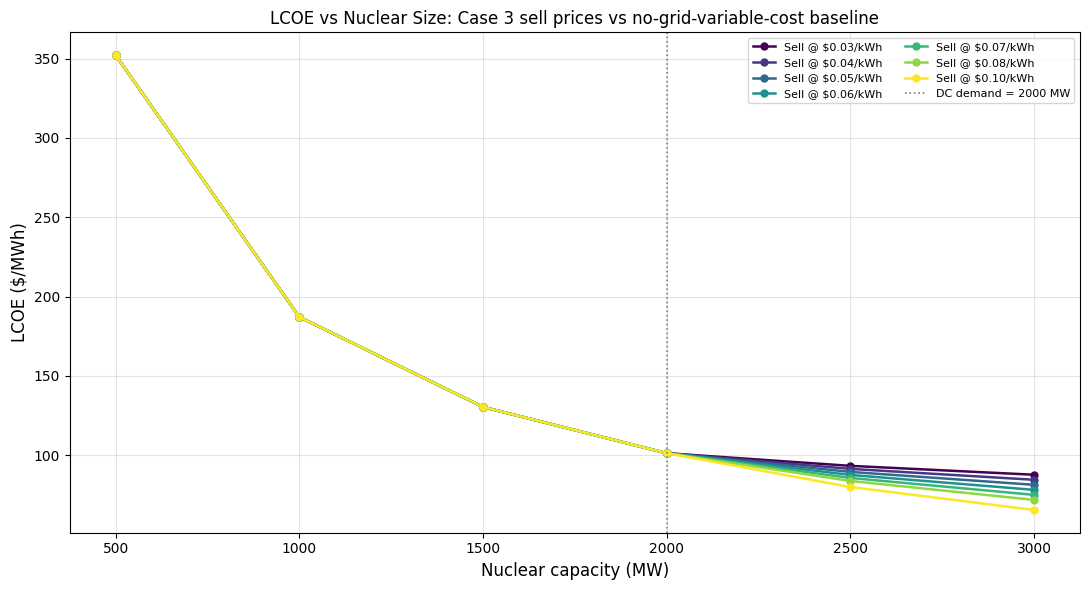

In [32]:
fig, ax = plt.subplots(figsize=(11, 6))

cmap   = plt.cm.viridis
colors = [cmap(k / (len(SWEEP2_SELL_PRICE) - 1)) for k in range(len(SWEEP2_SELL_PRICE))]

for j, (sell_p, color) in enumerate(zip(SWEEP2_SELL_PRICE, colors)):
    ax.plot(
        SWEEP2_NUC_MW,
        lcoe_matrix[:, j],
        'o-', color=color, lw=1.8, ms=5,
        label=f'Sell @ ${sell_p:.2f}/kWh'
    )


ax.axvline(DC_DEMAND_MW, color='gray', linestyle=':', lw=1.2,
           label=f'DC demand = {DC_DEMAND_MW} MW')
ax.set_xlabel('Nuclear capacity (MW)', fontsize=12)
ax.set_ylabel('LCOE ($/MWh)', fontsize=12)
ax.set_title(
    'LCOE vs Nuclear Size: Case 3 sell prices vs no-grid-variable-cost baseline',
    fontsize=12
)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('case3_lcoe_vs_size_sellprice.png', dpi=150, bbox_inches='tight')
plt.show()